# Úkol 1


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, HTML

def rastrigin(x):
    d = x.shape[-1]
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=-1)

def ackley(x):
    d = x.shape[-1]
    term1 = -20 * np.exp(-0.2 * np.sqrt(np.sum(x**2, axis=-1) / d))
    term2 = -np.exp(np.sum(np.cos(2 * np.pi * x), axis=-1) / d)
    return term1 + term2 + 20 + np.e

def sphere(x):
    return np.sum(x**2, axis=-1)

def rosenbrock(x):
    return np.sum(100 * (x[..., 1:] - x[..., :-1]**2)**2 + (1 - x[..., :-1])**2, axis=-1)

def griewank(x):
    sum_part = np.sum(x**2 / 4000, axis=-1)
    prod_part = np.prod(np.cos(x / np.sqrt(np.arange(1, x.shape[-1] + 1))), axis=-1)
    return sum_part - prod_part + 1

def random_search(func, dim, low, high, max_fes):
    best_fitness = float('inf')
    convergence_curve = []
    
    for fes in range(1, max_fes + 1):
        candidate = np.random.uniform(low, high, dim)
        fitness = func(candidate)
        
        if fitness < best_fitness:
            best_fitness = fitness
        
        if fes % 100 == 0 or fes == 1:
            convergence_curve.append(best_fitness)
            
    return best_fitness, np.array(convergence_curve)

def run_experiment_for_function(name, func_data, dimensions=[5, 10, 20], runs=30):
    func, low, high, _ = func_data
    
    fig = plt.figure(figsize=(14, 5))
    
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    x_lin = np.linspace(low, high, 100)
    X, Y = np.meshgrid(x_lin, x_lin)
    Z = np.array([func(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', antialiased=False, alpha=0.8)
    ax1.set_title(f"Povrch funkce {name} (D=2)")
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

    ax2 = fig.add_subplot(1, 2, 2)
    stats_list = []

    for d in dimensions:
        max_fes = 10000 * d
        run_bests = []
        all_curves = []
        
        for r in range(runs):
            best_f, curve = random_search(func, d, low, high, max_fes)
            run_bests.append(best_f)
            all_curves.append(curve)
        
        stats_list.append({
            "Dimenze": d, 
            "Minimum": f"{np.min(run_bests):.4e}", 
            "Maximum": f"{np.max(run_bests):.4e}", 
            "Průměr": f"{np.mean(run_bests):.4e}"
        })
        
        avg_curve = np.mean(all_curves, axis=0)
        fes_axis = np.linspace(1, max_fes, len(avg_curve))
        ax2.plot(fes_axis, avg_curve, label=f"D={d}")

    ax2.set_yscale('log')
    ax2.set_title(f"Konvergence: {name}")
    ax2.set_xlabel("FES")
    ax2.set_ylabel("Best Fitness (log)")
    ax2.legend()
    ax2.grid(True, which="both", ls="-", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nStatistické výsledky pro funkci: {name}")
    df = pd.DataFrame(stats_list)
    display(HTML(df.to_html(index=False, classes='table table-striped')))
    print("-" * 100)

FUNCTIONS = {
    "Rastrigin": (rastrigin, -5.12, 5.12, 0),
    "Ackley": (ackley, -32.768, 32.768, 0),
    "Sphere": (sphere, -5.12, 5.12, 0),
    "Rosenbrock": (rosenbrock, -30, 30, 0),
    "Griewank": (griewank, -600, 600, 0)
}


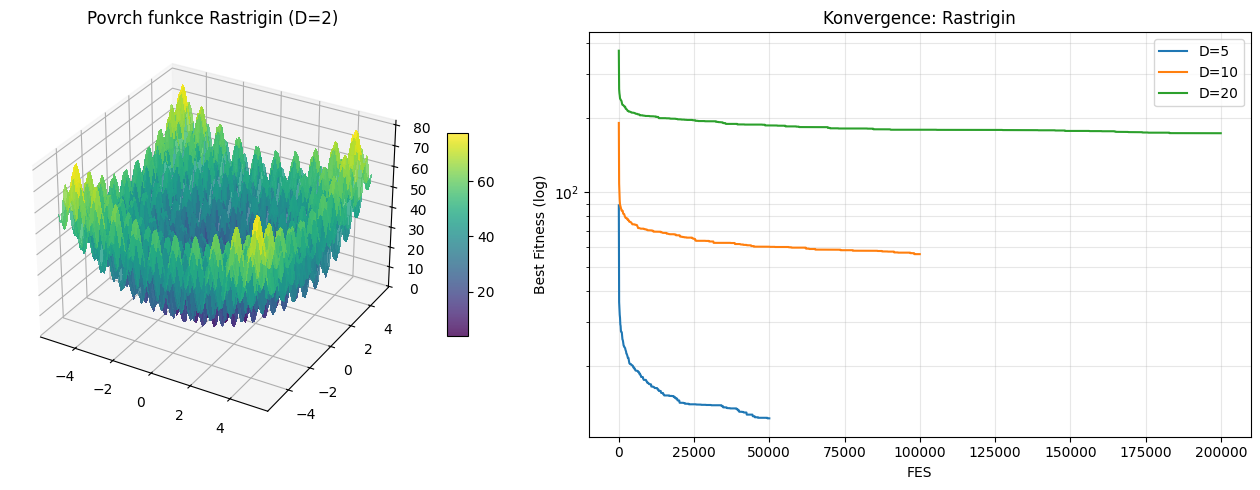


Statistické výsledky pro funkci: Rastrigin


Dimenze,Minimum,Maximum,Průměr
5,6.2510e+00,1.8710e+01,1.2240e+01
10,4.3988e+01,6.8691e+01,5.6294e+01
20,1.5393e+02,1.8880e+02,1.7316e+02


----------------------------------------------------------------------------------------------------


In [2]:
run_experiment_for_function("Rastrigin", FUNCTIONS["Rastrigin"])


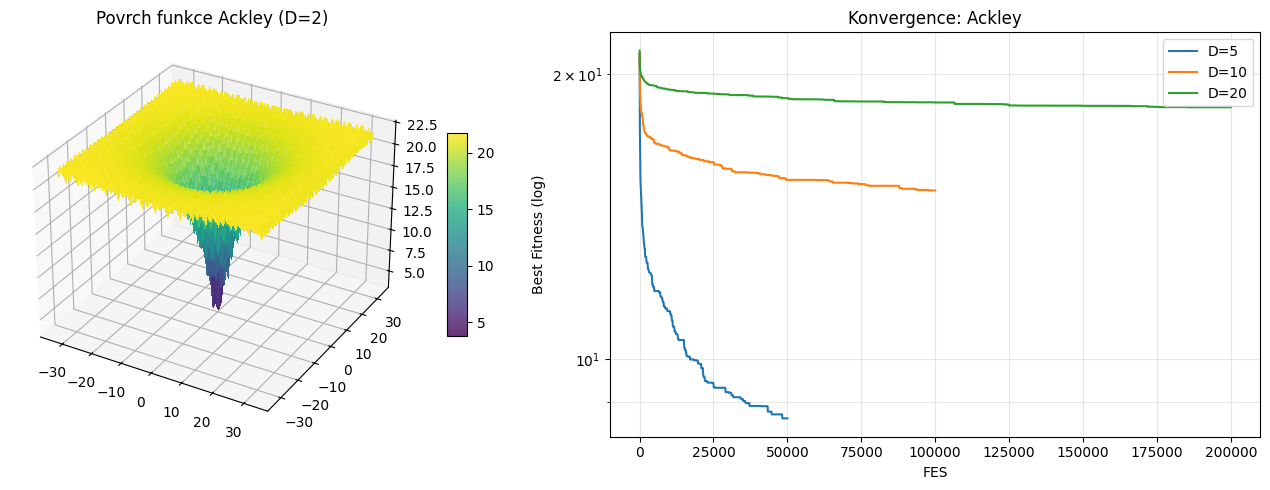


Statistické výsledky pro funkci: Ackley


Dimenze,Minimum,Maximum,Průměr
5,5.7036e+00,1.1139e+01,8.6574e+00
10,1.2213e+01,1.6720e+01,1.5070e+01
20,1.7055e+01,1.9224e+01,1.8449e+01


----------------------------------------------------------------------------------------------------


In [3]:
run_experiment_for_function("Ackley", FUNCTIONS["Ackley"])


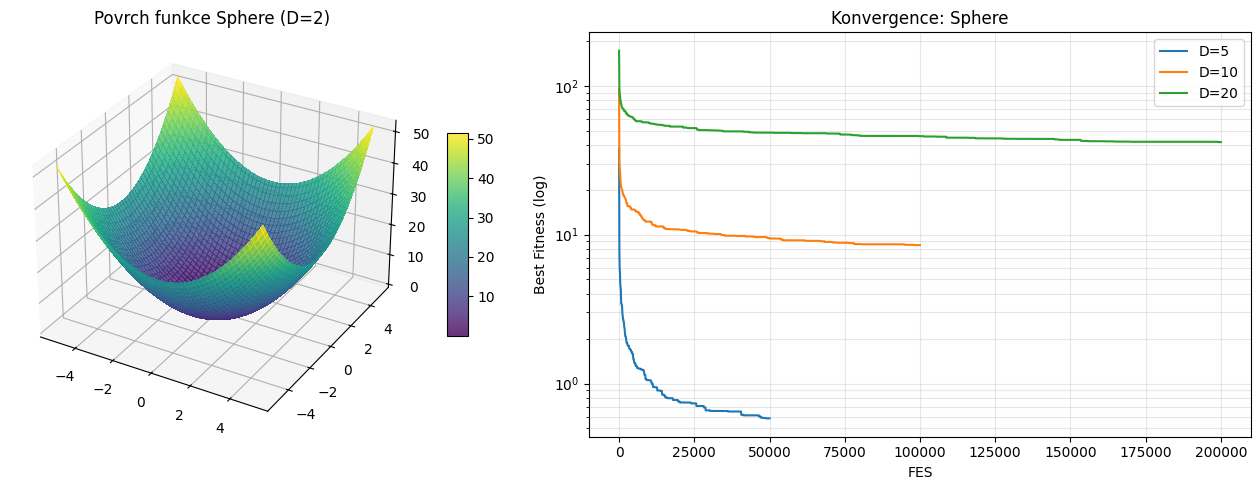


Statistické výsledky pro funkci: Sphere


Dimenze,Minimum,Maximum,Průměr
5,1.4328e-01,9.6313e-01,5.8338e-01
10,5.3915e+00,1.1882e+01,8.5034e+00
20,2.6299e+01,5.4498e+01,4.1851e+01


----------------------------------------------------------------------------------------------------


In [4]:
run_experiment_for_function("Sphere", FUNCTIONS["Sphere"])


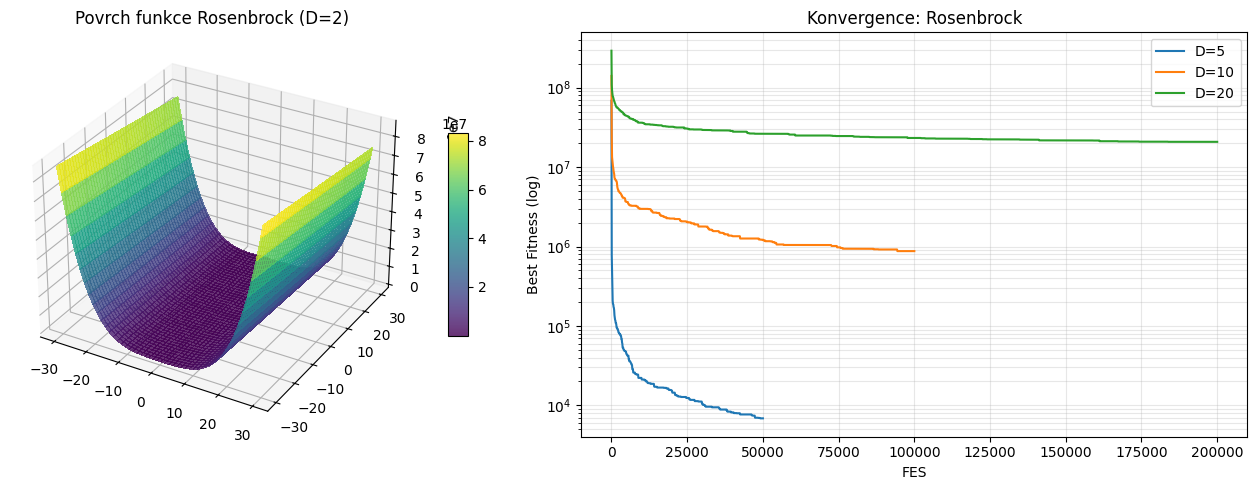


Statistické výsledky pro funkci: Rosenbrock


Dimenze,Minimum,Maximum,Průměr
5,9.6173e+02,1.4388e+04,6.8723e+03
10,1.5456e+05,1.6468e+06,8.7547e+05
20,1.1381e+07,3.2562e+07,2.0789e+07


----------------------------------------------------------------------------------------------------


In [5]:
run_experiment_for_function("Rosenbrock", FUNCTIONS["Rosenbrock"])


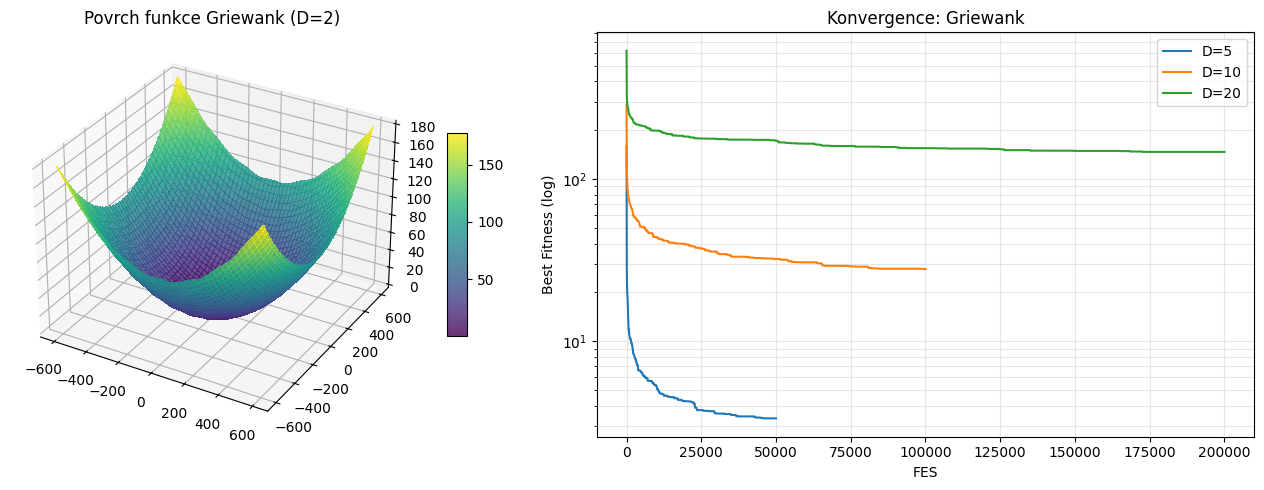


Statistické výsledky pro funkci: Griewank


Dimenze,Minimum,Maximum,Průměr
5,1.2355e+00,5.9260e+00,3.3416e+00
10,1.1129e+01,3.8518e+01,2.7854e+01
20,1.0144e+02,1.7858e+02,1.4700e+02


----------------------------------------------------------------------------------------------------


In [6]:
run_experiment_for_function("Griewank", FUNCTIONS["Griewank"])


## Komentář

| Funkce | Definiční obor | Globální minimum | Souřadnice minima |
|---|---|---|---|
| Sphere | $[-5.12, 5.12]^D$ | $f(x^*) = 0$ | $[0, \dots, 0]$ |
| Rastrigin | $[-5.12, 5.12]^D$ | $f(x^*) = 0$ | $[0, \dots, 0]$ |
| Ackley | $[-32.768, 32.768]^D$ | $f(x^*) = 0$ | $[0, \dots, 0]$ |
| Rosenbrock | $[-30, 30]^D$ | $f(x^*) = 0$ | $[1, \dots, 1]$ |
| Griewank | $[-600, 600]^D$ | $f(x^*) = 0$ | $[0, \dots, 0]$ |

**Sphere** je nejjednodušší unimodální funkce – má jedno globální minimum bez jakýchkoliv lokálních minim. Slouží jako základní referenční benchmark. Dosáhla nejlepších výsledků, což je dáno její unimodální strukturou, kde i náhodný bod má vyšší šanci spadnout do širší oblasti kolem globálního minima.

**Rastrigin** je multimodální funkce s velkým počtem lokálních minim rozmístěných pravidelně po celém prohledávacím prostoru. Globální minimum je obtížné najít právě kvůli hustotě lokálních pastí.

**Ackley** má relativně plochý vnější terén s výrazným strmým poklesem ke středu.

**Rosenbrock** je definovaná úzkým prohnutým údolím vedoucím k minimu. Minimum je sice technicky snadno identifikovatelné v 1D řezu, ale v D dimenzích vyžaduje koordinovanou změnu všech proměnných, což je pro čistě náhodné prohledávání velmi nepravděpodobné, že se stane.

**Griewank** je funkce s mnoha lokálními minimy překrytými sféroidním tvarem, přičemž vliv jednotlivých dimenzí na oscilační složku se liší díky dělení indexem dimenze.

---

Jednotlivé tabulky zobrazují výsledky 30 nezávislých běhů algoritmu Random Search pro dimenze $D \in \{5, 10, 20\}$. Z hodnot (minimum, maximum, průměr) je patrné, že s rostoucí složitostí funkcí a rozsahem hledání (zejména u funkcí Rosenbrock a Griewank) výrazně roste průměrná chyba, což naznačuje nízkou robustnost a vysokou náhodnost dosažených výsledků při pevně stanoveném počtu evaluací.

---

Z výsledků je patrné, že s rostoucí dimenzí výrazně klesá schopnost Random Search najít hodnoty blízké globálnímu optimu. U jednoduché Sphere funkce jsou výsledky pro $D=5$ přijatelné, ale při $D=20$ se průměrné nalezené hodnoty pohybují řádově výše než teoretické minimum. Důvodem je tzv. *curse of dimensionality* kdy objem prohledávacího prostoru roste exponenciálně s dimenzí, takže pevný počet náhodných bodů pokrývá stále menší relativní část prostoru.

Největší problém měl algoritmus s funkcí Rosenbrock, kde nestačí jen náhodně trefit oblast blízko minima. Naopak u Sphere, kde je minimum obklopeno velkým hladkým okolím, si Random Search vedl relativně nejlépe.

Obecně lze tedy říct, že Random Search je pro dimenze $D \geq 10$ u multimodálních funkcí prakticky nepoužitelný, ale může posloužit jako baseline pro porovnání s pokročilejšími metaheuristikami.
